# 02 Collect Sources

CORA coastal water level, ERA5 ocean waves, direct AORC SST rainfall members, and NWM soil-moisture context.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

location_root = Path("..").resolve()
repo_root = location_root.parents[1]
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))

# plan reruns, reuse reviewed data, and audit readiness.
import design_events.collect_sources.workflow as collect
from design_events.utils import load_runtime as load_design_event_runtime

config, paths = load_design_event_runtime(location_root / "config.yaml")
display(collect.summary(config, paths))

location                                                   marshfield
sources_root        /home/grahamhults/projects/Flood-RM/locations/...
collection_start                                           1979-02-01
collection_end                                             2022-12-31
Name: source_collection, dtype: str

## Rerun Control


In [2]:
rerun = False

## Source Collection Plan

In [3]:
plan = collect.plan(config, paths)
plan_table = collect.plan_table(
    plan,
    paths,
    rerun=rerun,
)
display(plan_table)


,source,start,end,will_reuse_existing,action
0,cora,1979-02-01,2022-12-31,False,collect or repair
1,nwm,1979-02-01,2022-12-31,False,collect or repair
2,aorc_sst,1979-02-01,2022-12-31,False,collect or repair
3,era5_waves,1979-02-01,2022-12-31,False,collect or repair
4,hurdat2,1979-02-01,2022-12-31,False,collect or repair


## CORA Coastal Water Level

CORA provides the historical boundary water-level series surge-event fitting. The downstream Event Catalog expects the hourly MSL CSV at `paths["waterlevel_csv"]`.


In [4]:
cora_path = paths["waterlevel_csv"]
if cora_path.exists():
    waterlevel = pd.read_csv(cora_path, parse_dates=["time"])
    display(pd.Series({"rows": len(waterlevel), "start": waterlevel["time"].min(), "end": waterlevel["time"].max(), "path": str(cora_path)}))
    display(waterlevel.head())
else:
    display(pd.Series({"status": "missing", "expected_path": str(cora_path)}))


rows                                                385681
start                                  1979-01-01 00:00:00
end                                    2022-12-31 00:00:00
path     /home/grahamhults/projects/Flood-RM/locations/...
dtype: object

,time,value
0,1979-01-01 00:00:00,-1.660526
1,1979-01-01 01:00:00,-1.154254
2,1979-01-01 02:00:00,-0.318566
3,1979-01-01 03:00:00,0.595984
4,1979-01-01 04:00:00,1.224257


## ERA5 Ocean Waves

Marshfield is wave-enabled. The configured Earth Data Hub ERA5 ocean-wave Zarr variables are staged into a local NetCDF for SnapWave/SFINCS coupling.

In [5]:
waves = config["collection"].get("era5_waves", {})
display(pd.Series({
    "provider": waves.get("provider"),
    "bbox_wgs84": waves.get("bbox_wgs84"),
    "output": str(paths["era5_waves_nc"]),
    "exists": paths["era5_waves_nc"].exists(),
}))


provider                                           earthdatahub
bbox_wgs84                           [-71.0, 42.0, -70.0, 42.5]
output        /home/grahamhults/projects/Flood-RM/locations/...
exists                                                     True
dtype: object

## Stochastic Storm Transposition Region

The SST region is defined in `config.yaml`

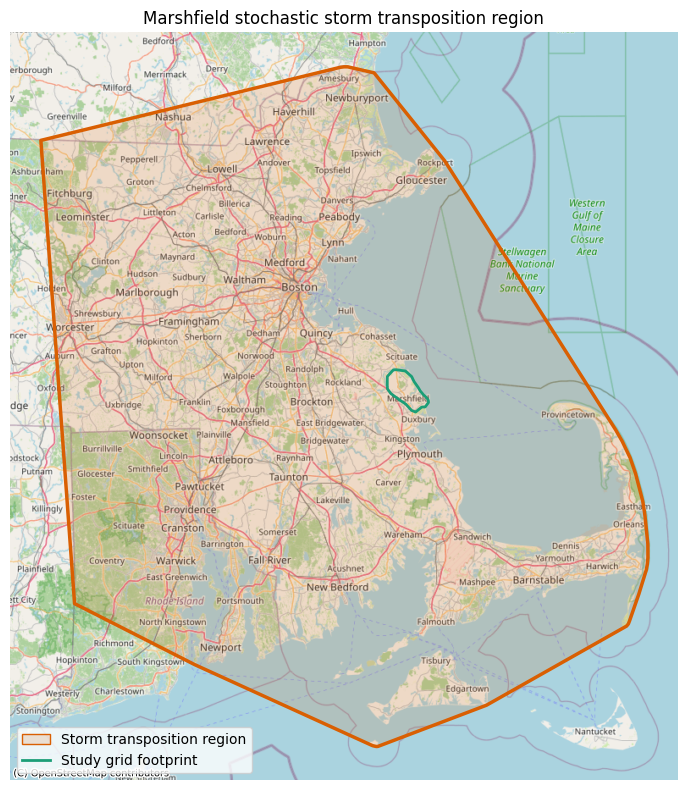

In [6]:
# Plot the configured AORC SST transposition region before pulling rainfall members.
fig, ax = collect.plot_sst_region(config, paths)

## Direct AORC SST Rainfall Members

The direct AORC SST collector scans the transposition region, ranks rolling storm windows, and writes the rainfall-member table for precipitation pairing with synthetic coastal water-level events.


In [7]:
# --- AORC SST collection parameters (edit to retune, then run Run Collection below) ---
# Threshold-driven POT: keep every INDEPENDENT storm whose 72h footprint-mean depth
# exceeds the threshold, so the rainfall-member count is data-driven
# Set the threshold from the rainfall POT diagnostics; raise it for fewer, heavier members.
min_precip_threshold = 60.0   # mm over the 72h storm window (footprint mean)
decluster_hours = 72          # minimum spacing between independent storms
storm_duration_hours = 72     # SST rainfall accumulation window
check_every_n_hours = 6       # transposition scan stride
defer_event_windows = True    # write AORC event-window NetCDFs in the separate cell below

display(collect.aorc_sst_params(
    config,
    paths,
    min_precip_threshold=min_precip_threshold,
    decluster_hours=decluster_hours,
    storm_duration_hours=storm_duration_hours,
    check_every_n_hours=check_every_n_hours,
    defer_event_windows=defer_event_windows,
))

source                                                       direct_aorc_sst
transposition_region_id                             east-atlantic-marshfield
transposition_region       data/sources/aorc_sst/transposition_regions/tr...
start_date                                                        1979-02-01
end_date                                                          2022-12-31
selection                  threshold-driven POT (every independent storm ...
min_precip_threshold_mm                                                 60.0
storm_duration_hours                                                      72
decluster_hours                                                           72
check_every_n_hours                                                        6
top_n_events_safety_cap                                                 None
rainfall_members           /home/grahamhults/projects/Flood-RM/locations/...
rainfall_members_exists                                                 True

## NWM Soil-Moisture Context

Marshfield has no meaningful streamflow boundary in the baseline, but selected NWM LDAS soil-moisture cells are retained for antecedent-condition pairing.


In [8]:
display(collect.soil_sources(config, paths))


version                                                                                3.0
streamflow_available                                                                 False
streamflow_reason                        Marshfield coastal SFINCS grid has no meaningf...
soil_moisture_points                                                                     0
soil_moisture_variables                                              [SOIL_M, SOILSAT_TOP]
soil_moisture_zarr                       s3://noaa-nwm-retrospective-3-0-pds/CONUS/zarr...
soil_moisture_csv                        /home/grahamhults/projects/Flood-RM/locations/...
soil_moisture_exists                                                                  True
soil_moisture_has_requested_variables                                                 True
Name: nwm_soil_moisture, dtype: object

## Run Collection

In [ ]:
# Collect any missing configured sources and summarize the artifacts.
collection_result_table = collect.run_collect(
    config,
    paths,
    plan,
    run_collection=True,
    skip_existing=not rerun,
)
display(collection_result_table)

CORA water level: reusing /home/grahamhults/projects/Flood-RM/locations/marshfield/data/sources/cora_waterlevel/cora_mfield_boundary_hourly_msl.csv (385,681 hourly rows, 1979-01-01 00:00:00 to 2022-12-31 00:00:00)


NWM sources:   0%|          | 0/2 [00:00<?, ?stage/s]

NWM streamflow: disabled; Marshfield coastal SFINCS grid has no meaningful streamflow driver or gage record for this baseline; do not use nearby tiny NWM reaches as a compound-flow input.
NWM soil moisture: opening s3://noaa-nwm-retrospective-3-0-pds/CONUS/zarr/ldasout.zarr
NWM soil moisture: deriving or skipping missing variables: SOILSAT_TOP
NWM soil moisture: extracting 9 representative points
NWM soil moisture: writing 4,619,232 rows to /home/grahamhults/projects/Flood-RM/locations/marshfield/data/sources/nwm/soil_moisture.csv


AORC SST years:   0%|          | 0/44 [00:00<?, ?year/s]

AORC selected storm windows:   0%|          | 0/495 [00:00<?, ?storm/s]

/home/grahamhults/projects/Flood-RM/.venv/lib/python3.13/site-packages/xarray/backends/netCDF4_.py:665: UserWarning: endian-ness of dtype and endian kwarg do not match, using endian kwarg
  nc4_var = self.ds.createVariable(**default_args)
/home/grahamhults/projects/Flood-RM/.venv/lib/python3.13/site-packages/xarray/backends/netCDF4_.py:665: UserWarning: endian-ness of dtype and endian kwarg do not match, using endian kwarg
  nc4_var = self.ds.createVariable(**default_args)
/home/grahamhults/projects/Flood-RM/.venv/lib/python3.13/site-packages/xarray/backends/netCDF4_.py:665: UserWarning: endian-ness of dtype and endian kwarg do not match, using endian kwarg
  nc4_var = self.ds.createVariable(**default_args)
/home/grahamhults/projects/Flood-RM/.venv/lib/python3.13/site-packages/xarray/backends/netCDF4_.py:665: UserWarning: endian-ness of dtype and endian kwarg do not match, using endian kwarg
  nc4_var = self.ds.createVariable(**default_args)
/home/grahamhults/projects/Flood-RM/.venv/li

## AORC SST Event Windows

In [ ]:
# Materialize missing per-storm AORC event-window NetCDFs after the ranked catalog exists.
aorc_event_window_result = collect.collect_aorc_sst_event_windows(
    config,
    paths,
    plan,
    skip_existing=True,
)
display(aorc_event_window_result)

## Collected Data Overview

### SST

In [ ]:
# Plot the SST region, study area, and rainfall transposition targets.
fig, ax = collect.plot_collected_sst_geography(config, paths)

### CORA Boundary Water Level

In [ ]:
# Plot the collected CORA boundary water level.
fig, ax = collect.plot_cora_boundary_water_level(paths)

### NWM Soil Moisture

In [ ]:
# Plot monthly mean NWM soil moisture variables when available.
fig, status = collect.plot_nwm_soil_moisture(config, paths)
display(status)

### AORC SST Rainfall

Rainfall members are shown as selected-event magnitude and distribution summaries.


In [ ]:
# Plot compact AORC SST rainfall member summaries.
fig = collect.plot_aorc_sst_rainfall(paths)

### ERA5 Wave Forcing

Wave variables are reduced to monthly spatial means for a compact quality check.


In [ ]:
# Plot compact ERA5 wave time series when available.
fig = collect.plot_era5_waves(paths)